In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd
X,y=make_blobs(n_samples=300,
               n_features=2,
               centers=3,
               random_state=0)
data=pd.DataFrame(X,columns=["Feature 1","Feature 2"])
print(data.shape)
print(data.head())

In [ ]:
import warnings
warnings.filterwarnings("ignore")
kmeans=KMeans(n_clusters=4,random_state=0)

labels=kmeans.fit_predict(data)
centroids=kmeans.cluster_centers_
print(labels)
print(centroids)

In [ ]:
import matplotlib.pyplot as plt
A,b=make_blobs(n_samples=400,n_features=4,centers=4,cluster_std=0.60,random_state=0)
df=pd.DataFrame(A,columns=["P","Q","R","S"])
kmeans=KMeans(n_clusters=4,random_state=0)
labels=kmeans.fit_predict(df)
print("Labels : \n",labels)
print("Centroids : \n",kmeans.cluster_centers_)


In [ ]:
print(df)

In [ ]:
centroids=kmeans.cluster_centers_
plt.scatter(A[:,0],A[:,1],s=50,c=kmeans.labels_,cmap="viridis")
plt.scatter(centroids[:,0],centroids[:,1],s=50,marker="o",c="black",label="centroids")
plt.legend()
plt.show()

In [ ]:
print("Elbow Method : ")
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / INERTIA")
plt.title("ELBOW METHOD")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=0)
    label=model.fit_predict(df)
    score=silhouette_score(df,label)
    print(f"Clusters :{k}, Silhouette Score {k} : {score:.2f}")

In [150]:
from PIL import Image
import numpy as np
image=Image.open("Passport Photo.jpg")
print("Image Compression in KNN")

print(image)
img=np.array(image)
print(img.shape)

Image Compression in KNN
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=796x1024 at 0x187492F9640>
(1024, 796, 3)


In [ ]:
pixels=img.reshape(-1,3)
print(pixels.shape)

In [158]:
model=KMeans(n_clusters=16,init="k-means++",n_init=10,max_iter=300,random_state=0)
labels=model.fit_predict(pixels)

compressed_image=model.cluster_centers_[labels]
compressed_image=compressed_image.reshape(img.shape)

In [159]:
model.cluster_centers_

array([[ 20.12335569,  30.99588283,  61.58679088],
       [219.90028164, 170.95462947, 172.42703749],
       [191.09698917, 210.00815185, 249.29626324],
       [  7.93076261,  29.02621524, 141.1259966 ],
       [110.91096609,  81.82268966,  87.33813075],
       [  7.04654678,   8.98296883,  19.18932409],
       [  2.38140162,  21.22905714, 117.31817939],
       [198.78310817, 151.17743467, 149.66268419],
       [ 16.0689045 ,  21.3579937 ,  40.23398772],
       [ 17.97758297,  40.23049445, 171.65169768],
       [145.5905763 , 107.01721952, 109.01501084],
       [ 62.58901301,  49.70637726,  59.15950226],
       [216.21982995, 234.05712639, 252.72794351],
       [  0.96174628,  13.71281668,  87.16976722],
       [147.58477404, 164.06976039, 213.64786169],
       [174.18926434, 129.65176147, 129.15282457]])

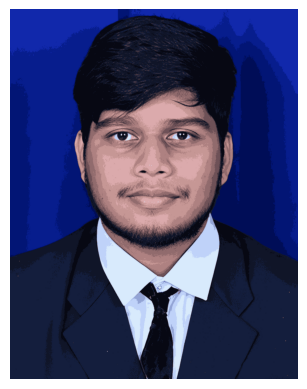

In [162]:
plt.imshow(compressed_image.astype(np.uint8))
plt.axis("off")
plt.show()

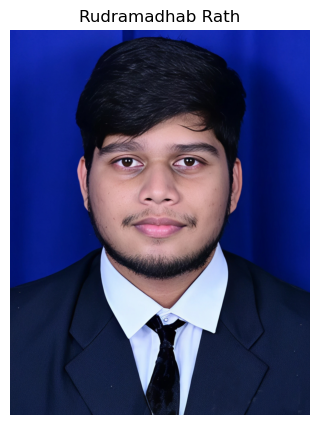

In [164]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Rudramadhab Rath")
plt.axis("off")
plt.show()

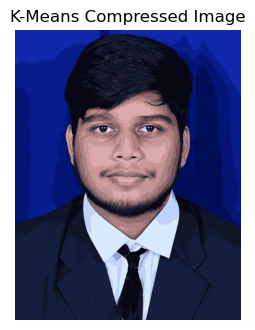

In [166]:
plt.subplot(1, 2, 2)
plt.imshow(compressed_image.astype(np.uint8))
plt.title("K-Means Compressed Image")
plt.axis("off")

plt.show()

In [170]:
compressed_image=compressed_image.astype(np.uint8)
compressed_pil=Image.fromarray(compressed_image)
compressed_pil.save("compressed_image.jpg")
